#### Install

In [1]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 810.4 kB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 7.4 MB/s eta 0:00:0000:0100:01


#### Seed, Plot, Multi-seed

In [2]:
import os
import random
import math
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F
from torch_geometric.utils import to_undirected
from torch_geometric.nn import GATv2Conv

from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    average_precision_score, confusion_matrix, classification_report
)

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

def plot_learning_curves(history: dict, model_name: str = "Model") -> None:
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    ax = axes[0]
    ax.plot(epochs, history['train_loss'], label='Train Loss')
    ax.plot(epochs, history['val_loss'], label='Val Loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title(f'{model_name} – Loss')
    ax.legend()
    ax.grid(True)

    ax = axes[1]
    ax.plot(epochs, history['train_f1'], label='Train F1 (illicit)')
    ax.plot(epochs, history['val_f1'], label='Val F1 (illicit)')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('F1-score')
    ax.set_title(f'{model_name} – F1 (illicit)')
    ax.legend()
    ax.grid(True)

    plt.tight_layout()
    plt.show()

def run_multiseed(run_single_seed_fn, exp_name="Experiment", seeds=[42, 0, 123]):
    results = []
    for seed in seeds:
        print(f"\n{exp_name} - Seed: {seed}")
        metrics = run_single_seed_fn(seed)
        metrics['seed'] = seed
        results.append(metrics)
        
    print(f"\n {exp_name} multi-seed results")
    metric_keys = [k for k in results[0].keys() if k != 'seed']
    
    for key in metric_keys:
        values = [res[key] for res in results]
        mean_val = np.mean(values)
        std_val = np.std(values)
        
        display_key = {'f1_ill': 'F1(illicit)', 'precision': 'Precision', 'recall': 'Recall', 'auc_pr': 'AUC-PR'}.get(key, key.capitalize())
        print(f"{display_key:<11}: {mean_val:.4f} ± {std_val:.4f}")
        
    return results


#### Integrate data processing logic and GAT model architecture

In [3]:
def load_and_preprocess_data(data_path: str, device: torch.device | None = None, undirected: bool = True) -> tuple:
    if device is None:
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Device: {device}")

    data = torch.load(data_path, weights_only=False)
    
    if undirected:
        data.edge_index = to_undirected(data.edge_index)

    train_features = data.x[data.train_mask]
    train_mean = train_features.mean(dim=0)
    train_std = train_features.std(dim=0)
    data.x = (data.x - train_mean) / (train_std + 1e-8)
    print(data)
    
    data = data.to(device)
    return data, device

class GAT(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=4, dropout=0.5):
        super().__init__()
        self.conv1 = GATv2Conv(in_channels, hidden_channels, heads=heads, dropout=dropout)
        self.conv2 = GATv2Conv(hidden_channels * heads, out_channels, heads=1, concat=False, dropout=dropout)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x

#### Consolidate model evaluation and early stopping loops

In [4]:
def compute_class_weights(data, device: torch.device) -> torch.Tensor:
    weight = torch.tensor([1.0, 1.5], dtype=torch.float).to(device)
    return weight

def evaluate(model, data, criterion, mask) -> dict:
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.edge_index)
        pred = out[mask].argmax(dim=1)
        probs = F.softmax(out[mask], dim=1)[:, 1]
        y_true, y_pred, y_prob = data.y[mask].cpu().numpy(), pred.cpu().numpy(), probs.cpu().numpy()
        loss = criterion(out[mask], data.y[mask]).item()

    return {
        'loss': loss, 'accuracy': accuracy_score(y_true, y_pred),
        'precision_ill': precision_score(y_true, y_pred, pos_label=1, zero_division=0), 
        'recall_ill': recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        'f1_ill': f1_score(y_true, y_pred, pos_label=1, zero_division=0), 
        'f1_macro': f1_score(y_true, y_pred, average='macro', zero_division=0), 
        'auc_pr': average_precision_score(y_true, y_prob),
    }

def train_one_epoch(model, data, optimizer, criterion, clip_grad_norm=None):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    if clip_grad_norm is not None:
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip_grad_norm)
    optimizer.step()
    return loss.item()

def train_with_early_stopping(model, data, optimizer, criterion, save_path: str, num_epochs: int = 200, patience: int = 20, monitor_metric: str = 'f1_ill', clip_grad_norm=None, scheduler=None) -> dict:
    history = {'train_loss': [], 'val_loss': [], 'train_f1': [], 'val_f1': []}
    best_val_score, epochs_no_improve, best_epoch = 0.0, 0, 0

    for epoch in range(1, num_epochs + 1):
        train_loss = train_one_epoch(model, data, optimizer, criterion, clip_grad_norm=clip_grad_norm)
        train_metrics = evaluate(model, data, criterion, data.train_mask)
        val_metrics = evaluate(model, data, criterion, data.val_mask)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_metrics['loss'])
        history['train_f1'].append(train_metrics['f1_ill'])
        history['val_f1'].append(val_metrics['f1_ill'])

        if scheduler is not None: scheduler.step()

        if val_metrics[monitor_metric] > best_val_score:
            best_val_score, best_epoch, epochs_no_improve = val_metrics[monitor_metric], epoch, 0
            torch.save(model.state_dict(), save_path)
        else:
            epochs_no_improve += 1

        print(f"Epoch {epoch:03d}: Train Loss={train_loss:.4f}, Val Loss={val_metrics['loss']:.4f}, Train F1={train_metrics['f1_ill']:.4f}, Val F1={val_metrics['f1_ill']:.4f}, Gap={train_metrics['f1_ill'] - val_metrics['f1_ill']:.4f}")

        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch} (Best epoch: {best_epoch})")
            break
    return history

def print_test_evaluation(model, data, criterion, label: str = "Test") -> dict:
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.edge_index)
        
        val_probs = F.softmax(out[data.val_mask], dim=1)[:, 1].cpu().numpy()
        y_val_true = data.y[data.val_mask].cpu().numpy()
        
        best_thresh = 0.5
        best_val_f1 = 0.0
        
        for thresh in np.arange(0.3, 0.86, 0.05):
            val_pred = (val_probs >= thresh).astype(int)
            f1 = f1_score(y_val_true, val_pred, pos_label=1, zero_division=0)
            if f1 > best_val_f1:
                best_val_f1 = f1
                best_thresh = thresh
                
        print(f"\n[Threshold Tuning] Optimal Threshold found on Validation set: {best_thresh:.2f} (Val F1: {best_val_f1:.4f})")
        
        test_probs = F.softmax(out[data.test_mask], dim=1)[:, 1]
        y_true = data.y[data.test_mask].cpu().numpy()
        y_prob = test_probs.cpu().numpy()
        y_pred = (y_prob >= best_thresh).astype(int)
        
        loss = criterion(out[data.test_mask], data.y[data.test_mask]).item()

    metrics = {
        'loss': loss, 'accuracy': accuracy_score(y_true, y_pred),
        'precision_ill': precision_score(y_true, y_pred, pos_label=1, zero_division=0), 
        'recall_ill': recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        'f1_ill': f1_score(y_true, y_pred, pos_label=1, zero_division=0), 
        'f1_macro': f1_score(y_true, y_pred, average='macro', zero_division=0), 
        'auc_pr': average_precision_score(y_true, y_prob),
    }

    print(f"\n{label} (Threshold = {best_thresh:.2f})\n"
          f"  Loss          : {metrics['loss']:.4f}\n"
          f"  Accuracy      : {metrics['accuracy']:.4f}\n"
          f"  Precision(ill): {metrics['precision_ill']:.4f}\n"
          f"  Recall(ill)   : {metrics['recall_ill']:.4f}\n"
          f"  F1(illicit)   : {metrics['f1_ill']:.4f}\n"
          f"  F1(macro)     : {metrics['f1_macro']:.4f}\n"
          f"  AUC-PR        : {metrics['auc_pr']:.4f}")

    print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=['Licit (0)', 'Illicit (1)'], digits=4, zero_division=0))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))

    return metrics

#### Implement main execution block pointing to Kaggle dataset paths

Device: cuda
Data(x=[203769, 165], edge_index=[2, 234355], y=[203769], train_mask=[203769], val_mask=[203769], test_mask=[203769])
Start training GAT on Kaggle

GAT - Seed: 42
GAT Train - Seed: 42
Epoch 001: Train Loss=1.1027, Val Loss=0.8061, Train F1=0.2767, Val F1=0.1783, Gap=0.0984
Epoch 002: Train Loss=1.4976, Val Loss=0.8048, Train F1=0.2780, Val F1=0.1796, Gap=0.0984
Epoch 003: Train Loss=1.1435, Val Loss=0.8034, Train F1=0.2802, Val F1=0.1831, Gap=0.0970
Epoch 004: Train Loss=1.2600, Val Loss=0.8021, Train F1=0.2817, Val F1=0.1855, Gap=0.0962
Epoch 005: Train Loss=1.0988, Val Loss=0.8008, Train F1=0.2853, Val F1=0.1882, Gap=0.0971
Epoch 006: Train Loss=1.1372, Val Loss=0.7996, Train F1=0.2875, Val F1=0.1909, Gap=0.0966
Epoch 007: Train Loss=1.1728, Val Loss=0.7984, Train F1=0.2893, Val F1=0.1917, Gap=0.0976
Epoch 008: Train Loss=1.2038, Val Loss=0.7971, Train F1=0.2917, Val F1=0.1917, Gap=0.1000
Epoch 009: Train Loss=1.2093, Val Loss=0.7955, Train F1=0.2944, Val F1=0.1932, Gap=

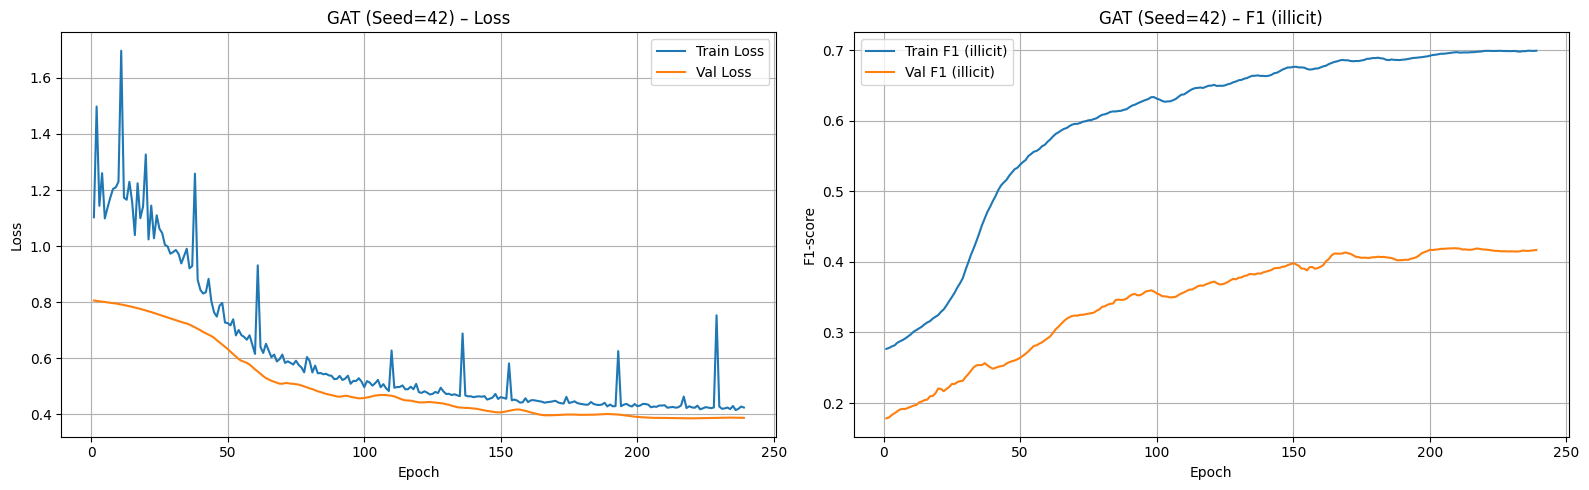


[Threshold Tuning] Optimal Threshold found on Validation set: 0.65 (Val F1: 0.5873)

GAT Test - Seed: 42 (Threshold = 0.65)
  Loss          : 0.4278
  Accuracy      : 0.9083
  Precision(ill): 0.5249
  Recall(ill)   : 0.5201
  F1(illicit)   : 0.5225
  F1(macro)     : 0.7359
  AUC-PR        : 0.5527

Classification Report:
               precision    recall  f1-score   support

   Licit (0)     0.9488    0.9497    0.9493      5132
 Illicit (1)     0.5249    0.5201    0.5225       548

    accuracy                         0.9083      5680
   macro avg     0.7368    0.7349    0.7359      5680
weighted avg     0.9079    0.9083    0.9081      5680

Confusion Matrix:
 [[4874  258]
 [ 263  285]]

GAT - Seed: 0
GAT Train - Seed: 0
Epoch 001: Train Loss=1.2378, Val Loss=0.8044, Train F1=0.2468, Val F1=0.1576, Gap=0.0892
Epoch 002: Train Loss=1.2865, Val Loss=0.8039, Train F1=0.2470, Val F1=0.1576, Gap=0.0894
Epoch 003: Train Loss=1.2391, Val Loss=0.8033, Train F1=0.2472, Val F1=0.1577, Gap=0.08

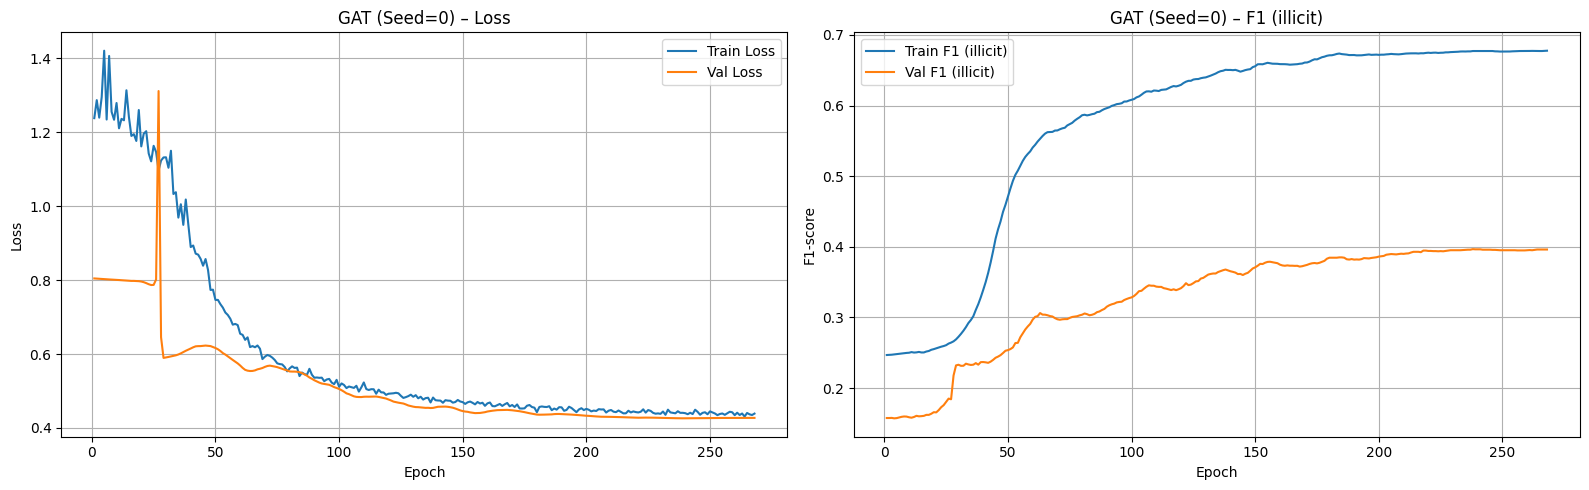


[Threshold Tuning] Optimal Threshold found on Validation set: 0.65 (Val F1: 0.4895)

GAT Test - Seed: 0 (Threshold = 0.65)
  Loss          : 0.4650
  Accuracy      : 0.9051
  Precision(ill): 0.5091
  Recall(ill)   : 0.4599
  F1(illicit)   : 0.4832
  F1(macro)     : 0.7155
  AUC-PR        : 0.4953

Classification Report:
               precision    recall  f1-score   support

   Licit (0)     0.9429    0.9527    0.9478      5132
 Illicit (1)     0.5091    0.4599    0.4832       548

    accuracy                         0.9051      5680
   macro avg     0.7260    0.7063    0.7155      5680
weighted avg     0.9011    0.9051    0.9029      5680

Confusion Matrix:
 [[4889  243]
 [ 296  252]]

GAT - Seed: 123
GAT Train - Seed: 123
Epoch 001: Train Loss=1.6311, Val Loss=1.6181, Train F1=0.2949, Val F1=0.1697, Gap=0.1252
Epoch 002: Train Loss=1.7530, Val Loss=1.6127, Train F1=0.2957, Val F1=0.1699, Gap=0.1258
Epoch 003: Train Loss=1.6641, Val Loss=1.6080, Train F1=0.2963, Val F1=0.1697, Gap=0

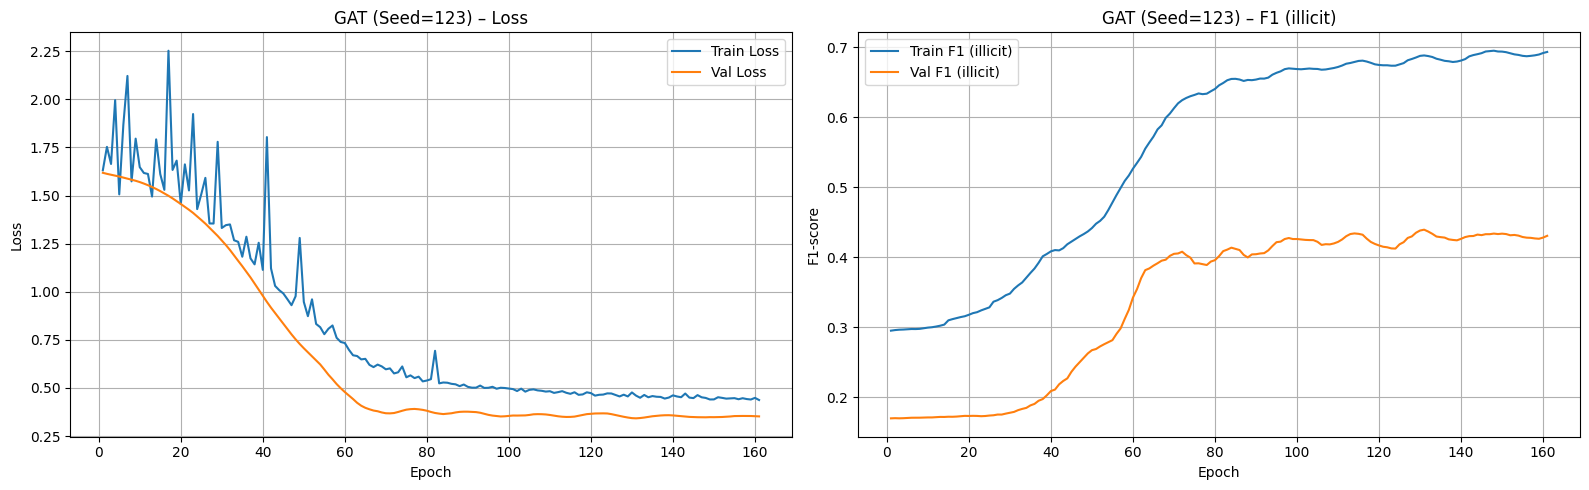


[Threshold Tuning] Optimal Threshold found on Validation set: 0.70 (Val F1: 0.6148)

GAT Test - Seed: 123 (Threshold = 0.70)
  Loss          : 0.3482
  Accuracy      : 0.9217
  Precision(ill): 0.6217
  Recall(ill)   : 0.4799
  F1(illicit)   : 0.5417
  F1(macro)     : 0.7494
  AUC-PR        : 0.5972

Classification Report:
               precision    recall  f1-score   support

   Licit (0)     0.9458    0.9688    0.9572      5132
 Illicit (1)     0.6217    0.4799    0.5417       548

    accuracy                         0.9217      5680
   macro avg     0.7838    0.7244    0.7494      5680
weighted avg     0.9145    0.9217    0.9171      5680

Confusion Matrix:
 [[4972  160]
 [ 285  263]]

 GAT multi-seed results
Loss       : 0.4136 ± 0.0487
Accuracy   : 0.9117 ± 0.0072
Precision_ill: 0.5519 ± 0.0498
Recall_ill : 0.4866 ± 0.0250
F1(illicit): 0.5158 ± 0.0243
F1_macro   : 0.7336 ± 0.0140
AUC-PR     : 0.5484 ± 0.0417


In [5]:
data_path = '/kaggle/input/datasets/meowll/elliptic-graph-data/elliptic_pyg_data.pt'

data, device = load_and_preprocess_data(data_path, undirected=False)

def run_single_gcn_seed(seed):
    torch.cuda.empty_cache()
    set_seed(seed)
    print(f"GAT Train - Seed: {seed}")
    
    model = GAT(
        in_channels=data.x.shape[1], 
        hidden_channels=64,
        out_channels=2, 
        heads=2,  
        dropout=0.5
    ).to(device)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=5e-4)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=0.001, steps_per_epoch=1, epochs=300, pct_start=0.3,
    )
    weight = compute_class_weights(data, device)
    criterion = torch.nn.CrossEntropyLoss(weight=weight)
    
    save_path = f'/kaggle/working/gat_best_seed_{seed}.pt'
    
    history = train_with_early_stopping(
        model, data, optimizer, criterion, scheduler=scheduler,
        save_path=save_path, num_epochs=300, patience=30,
        monitor_metric='f1_ill', clip_grad_norm=1.0
    )
    
    plot_learning_curves(history, model_name=f"GAT (Seed={seed})")
    
    model.load_state_dict(torch.load(save_path))
    model.eval()
    
    test_metrics = print_test_evaluation(model, data, criterion, label=f"GAT Test - Seed: {seed}")
    
    return test_metrics

print("Start training GAT on Kaggle")
results = run_multiseed(run_single_gcn_seed, "GAT", seeds=[42, 0, 123])